In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette('muted')

DB_PATH = '../data/supply_chain.db'
conn = sqlite3.connect(DB_PATH)

print("Connection opened. Ready for EDA.")

Connection opened. Ready for EDA.


In [2]:
def query(sql):
    """Run a SQL query and return a DataFrame."""
    return pd.read_sql(sql, conn)

# Quick sanity check
query("SELECT COUNT(*) as total_orders FROM fact_orders")

,total_orders
0,180519


In [3]:
kpi = query("""
    SELECT
        COUNT(*)                                    AS total_orders,
        ROUND(SUM(sales_amount), 2)                 AS total_revenue,
        ROUND(AVG(sales_amount), 2)                 AS avg_order_value,
        ROUND(AVG(is_late) * 100, 1)                AS late_delivery_pct,
        ROUND(AVG(days_late), 1)                    AS avg_days_late,
        ROUND(SUM(order_profit_per_order), 2)       AS total_profit
    FROM fact_orders
""")

print("=" * 45)
print("  SUPPLY CHAIN INTELLIGENCE — KPI SUMMARY")
print("=" * 45)
print(f"  Total Orders        : {kpi['total_orders'][0]:>12,.0f}")
print(f"  Total Revenue       : ${kpi['total_revenue'][0]:>12,.2f}")
print(f"  Total Profit        : ${kpi['total_profit'][0]:>12,.2f}")
print(f"  Avg Order Value     : ${kpi['avg_order_value'][0]:>12,.2f}")
print(f"  Late Delivery %     : {kpi['late_delivery_pct'][0]:>11.1f}%")
print(f"  Avg Days Late       : {kpi['avg_days_late'][0]:>11.1f} days")
print("=" * 45)

  SUPPLY CHAIN INTELLIGENCE — KPI SUMMARY
  Total Orders        :      180,519
  Total Revenue       : $36,784,735.01
  Total Profit        : $3,966,902.97
  Avg Order Value     : $      203.77
  Late Delivery %     :        57.3%
  Avg Days Late       :         0.6 days


 shipping_mode  total_orders  late_orders  late_rate_pct  avg_days_late  total_revenue
   First Class         27814        27814          100.0            1.0     5674369.76
  Second Class         35216        28078           79.7            2.0     7145444.82
      Same Day          9737         4657           47.8            0.5     1942528.56
Standard Class        107752        42851           39.8           -0.0    22022391.88


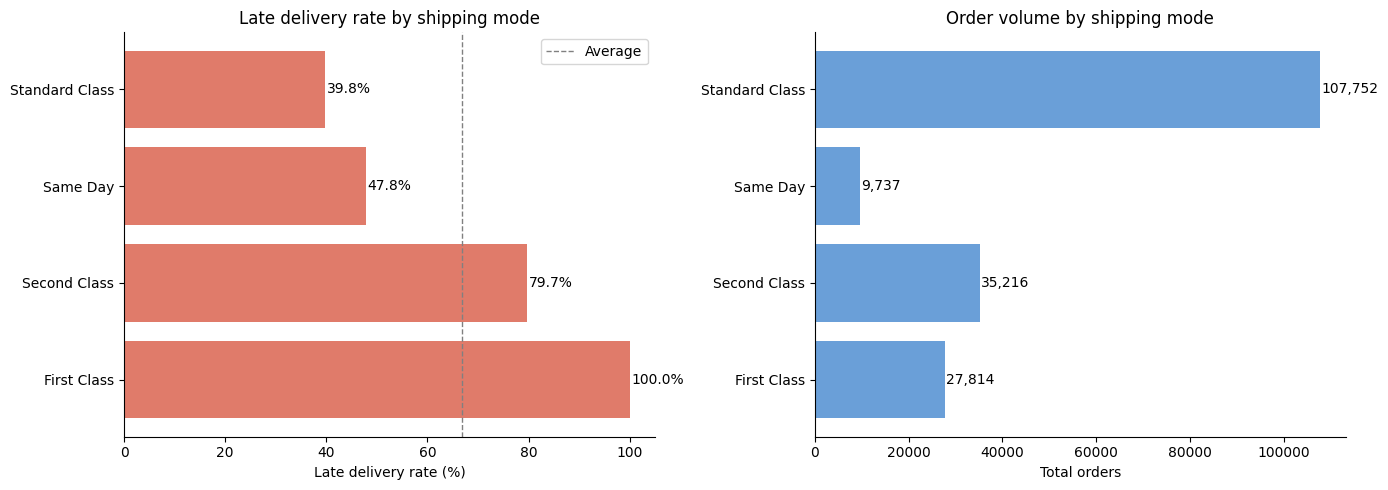

Chart saved.


In [ ]:
# Late delivery rate by shipping mode

shipping = query("""
    SELECT
        l.shipping_mode,
        COUNT(*)                            AS total_orders,
        SUM(f.is_late)                      AS late_orders,
        ROUND(AVG(f.is_late) * 100, 1)      AS late_rate_pct,
        ROUND(AVG(f.days_late), 1)          AS avg_days_late,
        ROUND(SUM(f.sales_amount), 2)       AS total_revenue
    FROM fact_orders f
    JOIN dim_location l ON f.location_id = l.location_id
    GROUP BY l.shipping_mode
    ORDER BY late_rate_pct DESC
""")

print(shipping.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — late rate by shipping mode
bars = axes[0].barh(shipping['shipping_mode'], shipping['late_rate_pct'], color='#e07b6a')
axes[0].set_xlabel('Late delivery rate (%)')
axes[0].set_title('Late delivery rate by shipping mode')
axes[0].axvline(x=shipping['late_rate_pct'].mean(), color='gray',
                linestyle='--', linewidth=1, label='Average')
axes[0].legend()
for bar, val in zip(bars, shipping['late_rate_pct']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=10)

# Chart 2 — total orders by shipping mode
axes[1].barh(shipping['shipping_mode'], shipping['total_orders'], color='#6a9fd8')
axes[1].set_xlabel('Total orders')
axes[1].set_title('Order volume by shipping mode')
for bar, val in zip(axes[1].patches, shipping['total_orders']):
    axes[1].text(val + 200, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/chart_01_shipping_mode.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Finding 1 — Shipping mode is the primary driver of late deliveries

- First Class has a 100% late delivery rate across 27,814 orders — every order late
- Second Class averages 2.0 days late with a 79.7% late rate
- Standard Class generates the most absolute late orders (42,851) due to high volume
- Same Day shipping fails to deliver on time 47.8% of the time

**Business implication:** Premium shipping modes (First Class, Second Class) 
are performing worse than Standard Class. This suggests a systemic mislabelling 
or fulfilment process failure — not a capacity issue.

   order_region  total_orders  late_rate_pct  avg_days_late  total_revenue  revenue_at_risk
 Central Africa          1677           60.7            0.6      327263.02        196252.41
 Western Europe         27109           58.5            0.6     5894380.77       3447206.73
     South Asia          7731           58.5            0.6     1553680.92        903907.65
 South of  USA           4045           58.1            0.6      785783.95        454815.92
 Southeast Asia          9539           58.0            0.6     1932495.57       1121253.76
    East of USA          6915           58.0            0.6     1371111.99        785768.94
      West Asia          6009           57.5            0.6     1174671.78        683136.04
    East Africa          1852           57.5            0.6      376234.90        216431.18
 Eastern Europe          3920           57.4            0.6      774266.57        447175.94
  South America         14935           57.2            0.6     2960881.41      

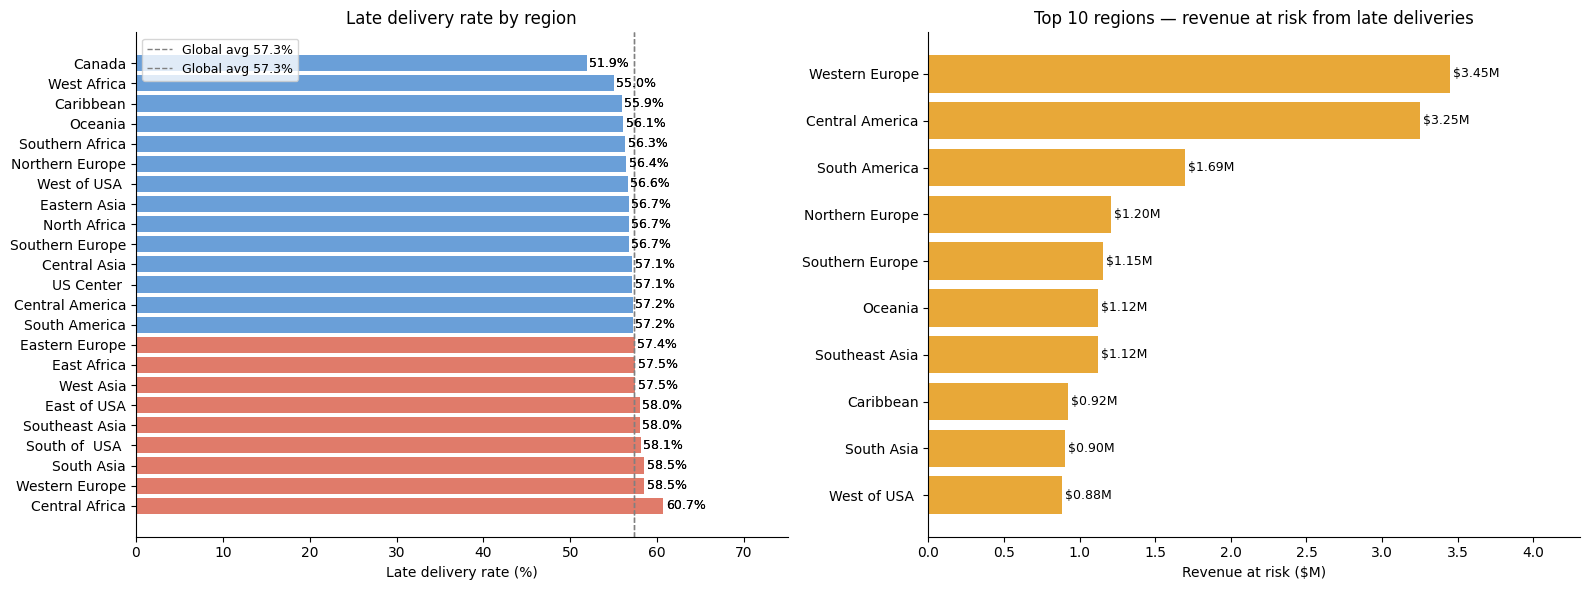


Top 5 regions by revenue at risk:
   order_region  total_orders  late_rate_pct  revenue_at_risk
 Western Europe         27109           58.5       3447206.73
Central America         28341           57.2       3248824.90
  South America         14935           57.2       1694037.41
Northern Europe          9792           56.4       1204900.11
Southern Europe          9431           56.7       1151596.36


In [7]:
# Late delivery rate by region

region = query("""
    SELECT
        l.order_region,
        COUNT(*)                            AS total_orders,
        ROUND(AVG(f.is_late) * 100, 1)      AS late_rate_pct,
        ROUND(AVG(f.days_late), 1)          AS avg_days_late,
        ROUND(SUM(f.sales_amount), 2)       AS total_revenue,
        ROUND(SUM(f.sales_amount * f.is_late), 2) AS revenue_at_risk
    FROM fact_orders f
    JOIN dim_location l ON f.location_id = l.location_id
    GROUP BY l.order_region
    ORDER BY late_rate_pct DESC
""")

print(region.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1 — late rate by region
colors = ['#e07b6a' if x > 57.3 else '#6a9fd8' for x in region['late_rate_pct']]
bars = axes[0].barh(region['order_region'], region['late_rate_pct'], color=colors)
axes[0].set_xlabel('Late delivery rate (%)')
axes[0].set_title('Late delivery rate by region')
axes[0].axvline(x=57.3, color='gray', linestyle='--', linewidth=1, label='Global avg 57.3%')
axes[0].legend(fontsize=9)
for bar, val in zip(bars, region['late_rate_pct']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=9)

# Chart 2 — revenue at risk by regfig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Chart 1 — late rate by region (sorted)
region_sorted = region.sort_values('late_rate_pct', ascending=True)
colors = ['#e07b6a' if x > 57.3 else '#6a9fd8' for x in region_sorted['late_rate_pct']]
bars = axes[0].barh(region_sorted['order_region'], region_sorted['late_rate_pct'], color=colors)
axes[0].set_xlabel('Late delivery rate (%)')
axes[0].set_title('Late delivery rate by region')
axes[0].axvline(x=57.3, color='gray', linestyle='--', linewidth=1, label='Global avg 57.3%')
axes[0].legend(fontsize=9)
axes[0].set_xlim(0, 75)
for bar, val in zip(bars, region_sorted['late_rate_pct']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=9)

# Chart 2 — revenue at risk by region (top 10)
top10 = region.sort_values('revenue_at_risk', ascending=True).tail(10)
axes[1].barh(top10['order_region'], top10['revenue_at_risk'] / 1_000_000, color='#e8a838')
axes[1].set_xlabel('Revenue at risk ($M)')
axes[1].set_title('Top 10 regions — revenue at risk from late deliveries')
axes[1].set_xlim(0, top10['revenue_at_risk'].max() / 1_000_000 * 1.25)
for bar, val in zip(axes[1].patches, top10['revenue_at_risk'] / 1_000_000):
    axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                 f'${val:.2f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/chart_02_region_fixed.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 5 regions by revenue at risk
print("\nTop 5 regions by revenue at risk:")
print(region.sort_values('revenue_at_risk', ascending=False)[
    ['order_region','total_orders','late_rate_pct','revenue_at_risk']
].head(5).to_string(index=False))

## Finding 2 — Late delivery is a global systemic problem, not regional

- All 23 regions have late delivery rates between 51.9% and 60.7%
- The 8.8% spread across regions is narrow — this is not a geography problem
- Western Europe has the highest absolute revenue at risk due to order volume
- Central Africa has the highest late rate (60.7%) but lowest volume impact
- avg_days_late is 0.6 days across almost every region — remarkably consistent

**Business implication:** Since the problem is uniform across all geographies,
the root cause lies in the fulfilment process itself — not last-mile delivery
or regional logistics. Fix the process, fix all regions simultaneously.

       category_name department_name  total_orders  total_revenue  late_rate_pct  revenue_at_risk  avg_profit_margin_pct
             Fishing        Fan Shop         17325     6929653.69           57.3       3971801.51                   12.1
              Cleats         Apparel         24551     4431942.78           57.3       2533078.74                   12.5
    Camping & Hiking        Fan Shop         13729     4118425.57           56.9       2343443.85                   11.6
    Cardio Equipment        Footwear         12487     3694843.20           56.9       2099461.62                   11.9
     Women's Apparel            Golf         21035     3147800.00           57.1       1798600.00                   12.2
        Water Sports        Fan Shop         15540     3113844.68           57.2       1781861.14                   11.6
      Men's Footwear         Apparel         22246     2891757.66           56.9       1646193.43                   12.0
Indoor/Outdoor Games        Fan 

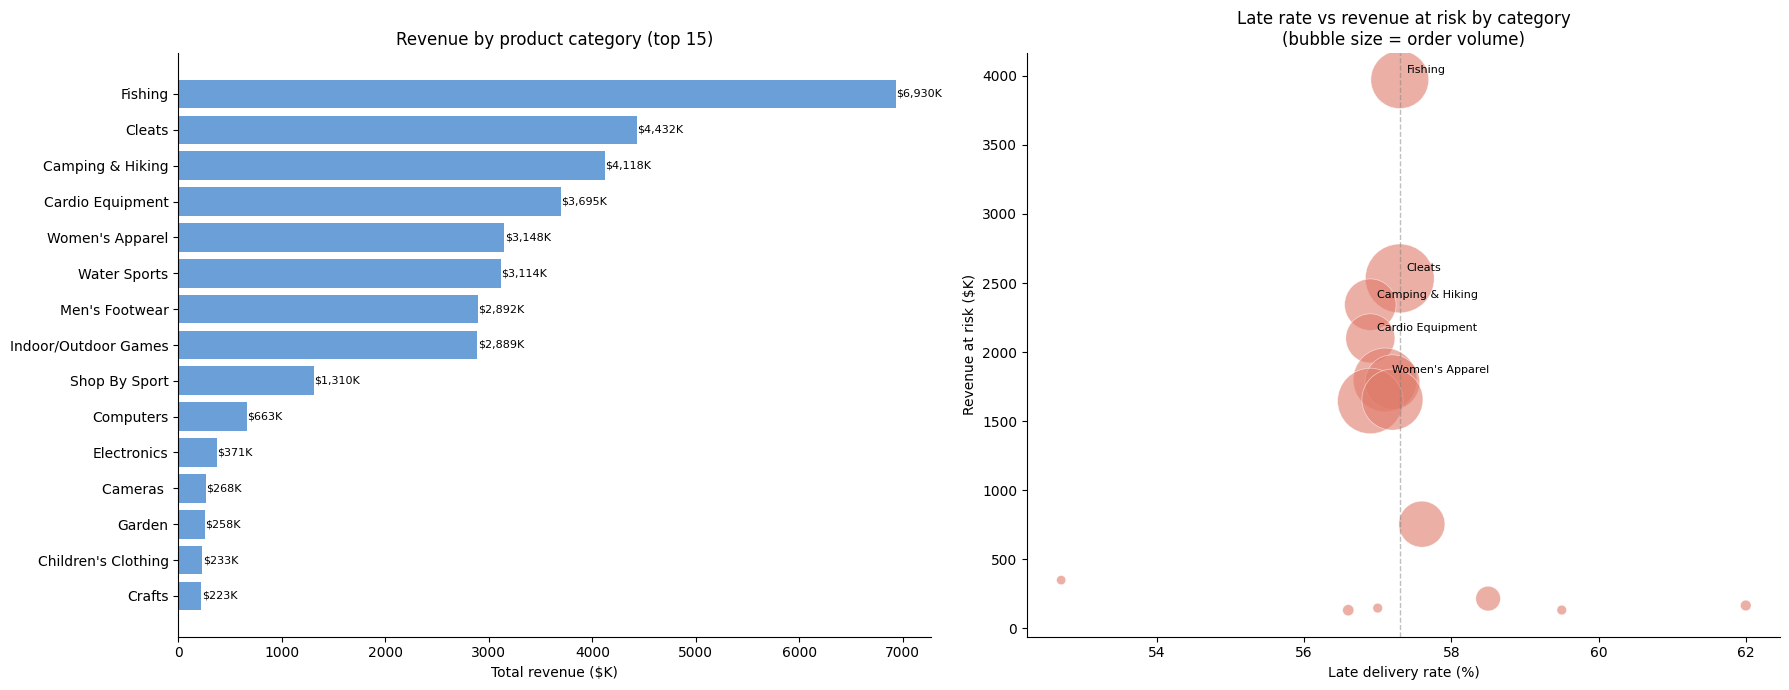

Chart saved.


In [9]:
# revenue and late rate by product category

category = query("""
    SELECT
        p.category_name,
        p.department_name,
        COUNT(*)                                        AS total_orders,
        ROUND(SUM(f.sales_amount), 2)                   AS total_revenue,
        ROUND(AVG(f.is_late) * 100, 1)                  AS late_rate_pct,
        ROUND(SUM(f.sales_amount * f.is_late), 2)       AS revenue_at_risk,
        ROUND(AVG(f.order_item_profit_ratio) * 100, 1)  AS avg_profit_margin_pct
    FROM fact_orders f
    JOIN dim_product p ON f.product_id = p.product_id
    GROUP BY p.category_name
    ORDER BY total_revenue DESC
    LIMIT 15
""")

print(category.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Chart 1 — revenue by category
cat_sorted = category.sort_values('total_revenue', ascending=True)
axes[0].barh(cat_sorted['category_name'], cat_sorted['total_revenue'] / 1000,
             color='#6a9fd8')
axes[0].set_xlabel('Total revenue ($K)')
axes[0].set_title('Revenue by product category (top 15)')
for bar, val in zip(axes[0].patches, cat_sorted['total_revenue'] / 1000):
    axes[0].text(val + 5, bar.get_y() + bar.get_height()/2,
                 f'${val:,.0f}K', va='center', fontsize=8)

# Chart 2 — revenue at risk vs late rate (bubble chart)
scatter = axes[1].scatter(
    category['late_rate_pct'],
    category['revenue_at_risk'] / 1000,
    s=category['total_orders'] / 10,
    alpha=0.6,
    color='#e07b6a',
    edgecolors='white',
    linewidth=0.5
)
axes[1].set_xlabel('Late delivery rate (%)')
axes[1].set_ylabel('Revenue at risk ($K)')
axes[1].set_title('Late rate vs revenue at risk by category\n(bubble size = order volume)')
axes[1].axvline(x=57.3, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Label top 5 by revenue at risk
top5 = category.nlargest(5, 'revenue_at_risk')
for _, row in top5.iterrows():
    axes[1].annotate(
        row['category_name'],
        xy=(row['late_rate_pct'], row['revenue_at_risk'] / 1000),
        xytext=(5, 5), textcoords='offset points', fontsize=8
    )

plt.tight_layout()
plt.savefig('../data/chart_03_category.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Finding 3 — Fishing, Cleats, and Camping & Hiking drive the most revenue at risk

- Fishing: $6.93M revenue, $3.97M at risk (57.3% late rate) — highest absolute risk
- Cleats: $4.43M revenue, $2.53M at risk — highest order volume at 24,551
- Top 5 categories account for $12.75M revenue at risk combined
- Cameras has the highest late rate (62%) but low volume — low business impact
- Profit margins are uniform across categories (11–14%) — margin issue is structural

**Business implication:** Prioritise fulfilment improvements for Fishing and 
Cleats — high volume, high revenue, and average late rates mean even a 10% 
improvement in on-time delivery recovers ~$650K in revenue at risk.

Date range: 2015-01 to 2018-01
Total months: 37
 year  month month_name year_month  total_orders  total_revenue  late_rate_pct
 2015      1    January    2015-01          5322     1051590.08           55.9
 2015      2   February    2015-02          4729      927009.90           57.9
 2015      3      March    2015-03          5362     1051253.69           57.2
 2015      4      April    2015-04          5126     1014463.28           56.4
 2015      5        May    2015-05          5357     1050478.44           58.1


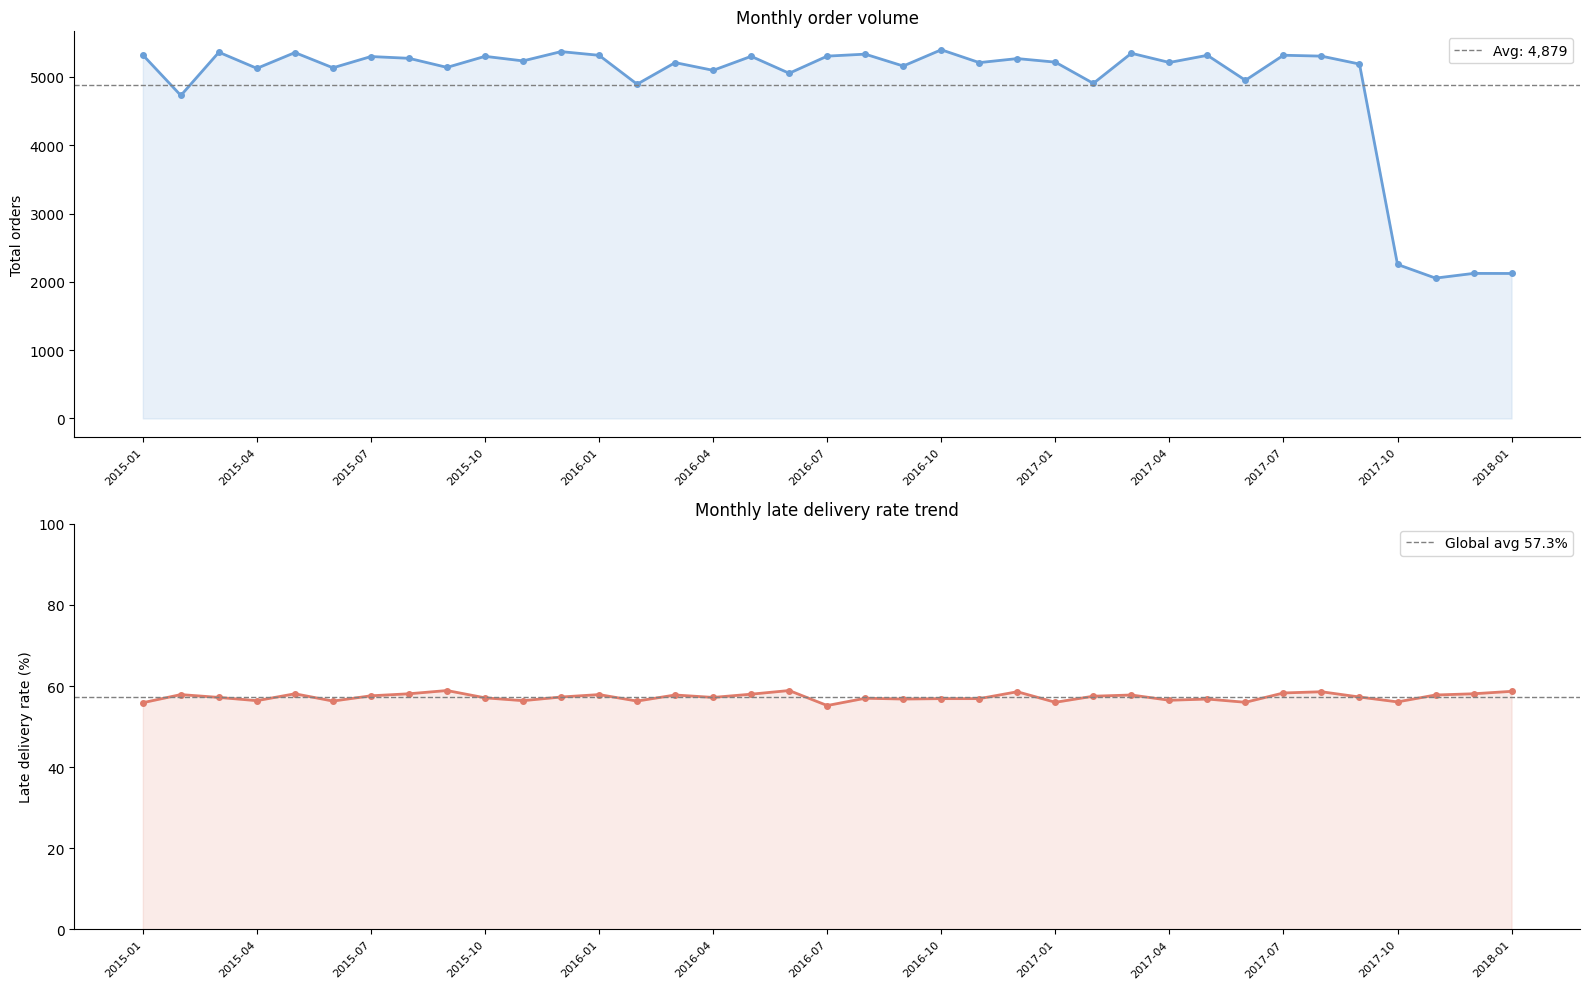

Chart saved.


In [11]:
## Monthly order volume trend

monthly = query("""
    SELECT
        d.year,
        d.month,
        d.month_name,
        d.year || '-' || printf('%02d', d.month)    AS year_month,
        COUNT(*)                                     AS total_orders,
        ROUND(SUM(f.sales_amount), 2)                AS total_revenue,
        ROUND(AVG(f.is_late) * 100, 1)               AS late_rate_pct
    FROM fact_orders f
    JOIN dim_date d ON f.date_id = d.date_id
    GROUP BY d.year, d.month
    ORDER BY d.year, d.month
""")

print(f"Date range: {monthly['year_month'].min()} to {monthly['year_month'].max()}")
print(f"Total months: {len(monthly)}")
print(monthly.head(5).to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

x = range(len(monthly))

# Chart 1 — monthly order volume
axes[0].plot(x, monthly['total_orders'], color='#6a9fd8',
             linewidth=2, marker='o', markersize=4)
axes[0].fill_between(x, monthly['total_orders'], alpha=0.15, color='#6a9fd8')
axes[0].set_xticks(x[::3])
axes[0].set_xticklabels(monthly['year_month'].iloc[::3], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Total orders')
axes[0].set_title('Monthly order volume')
axes[0].axhline(y=monthly['total_orders'].mean(), color='gray',
                linestyle='--', linewidth=1, label=f"Avg: {monthly['total_orders'].mean():,.0f}")
axes[0].legend()

# Chart 2 — monthly late rate trend
axes[1].plot(x, monthly['late_rate_pct'], color='#e07b6a',
             linewidth=2, marker='o', markersize=4)
axes[1].fill_between(x, monthly['late_rate_pct'], alpha=0.15, color='#e07b6a')
axes[1].set_xticks(x[::3])
axes[1].set_xticklabels(monthly['year_month'].iloc[::3], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Late delivery rate (%)')
axes[1].set_title('Monthly late delivery rate trend')
axes[1].axhline(y=57.3, color='gray', linestyle='--',
                linewidth=1, label='Global avg 57.3%')
axes[1].set_ylim(0, 100)
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/chart_04_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Finding 4 — Late delivery rate has not improved in 3 years

- Monthly late rate stays between 55.9% and 60% for all 37 months
- No seasonal pattern, no improving trend — completely flat
- Order volume drops sharply from ~5,300 to ~2,100 in late 2017
- The 2017 drop is likely data truncation — not a real business event
- Dataset spans January 2015 to January 2018 (37 months)

**Business implication:** The flat late delivery trend over 3 years means 
no corrective action has been taken or has worked. This is not a temporary 
spike — it is the baseline operating state of the business. Structural 
intervention is required, not incremental fixes.

    segment  total_orders  total_revenue  avg_order_value  late_rate_pct  revenue_at_risk  avg_profit_margin_pct
   Consumer         93504    19095790.16           204.22           57.3      10932533.38                   12.1
  Corporate         54789    11168406.84           203.84           57.1       6360495.89                   12.1
Home Office         32226     6520538.02           202.34           57.5       3732155.89                   11.9


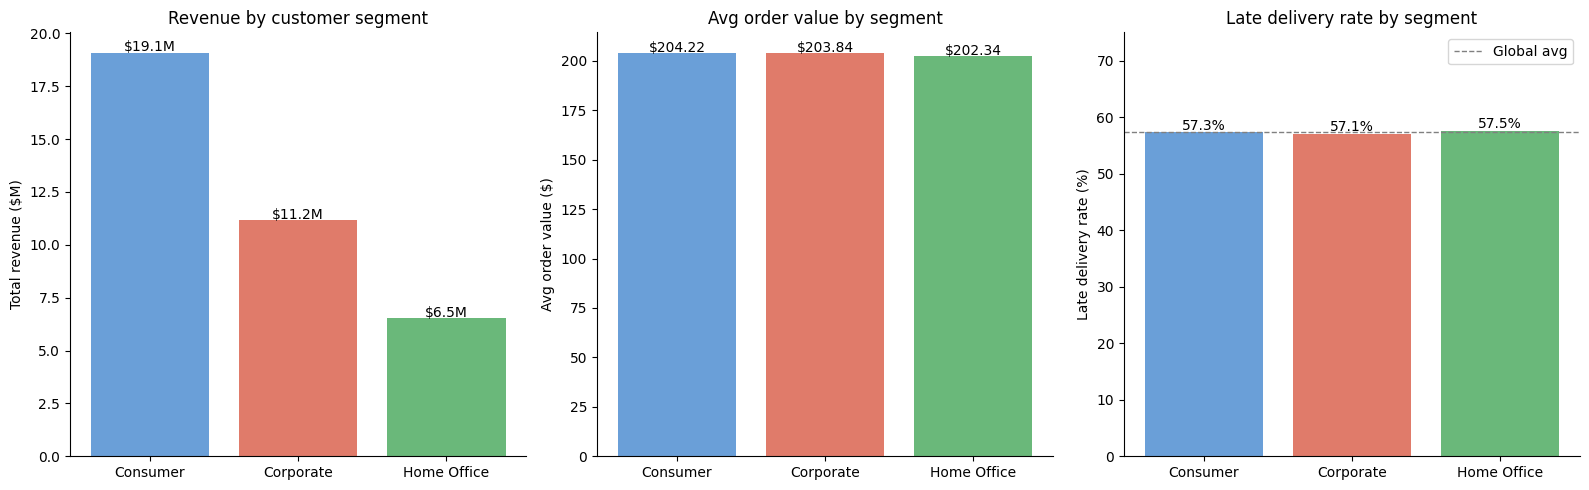

Chart saved.


In [14]:
# customer segment analysis

segment = query("""
    SELECT
        c.segment,
        COUNT(*)                                        AS total_orders,
        ROUND(SUM(f.sales_amount), 2)                   AS total_revenue,
        ROUND(AVG(f.sales_amount), 2)                   AS avg_order_value,
        ROUND(AVG(f.is_late) * 100, 1)                  AS late_rate_pct,
        ROUND(SUM(f.sales_amount * f.is_late), 2)       AS revenue_at_risk,
        ROUND(AVG(f.order_item_profit_ratio) * 100, 1)  AS avg_profit_margin_pct
    FROM fact_orders f
    JOIN dim_customer c ON f.customer_id = c.customer_id
    GROUP BY c.segment
    ORDER BY total_revenue DESC
""")

print(segment.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Chart 1 — revenue by segment
axes[0].bar(segment['segment'], segment['total_revenue'] / 1e6,
            color=['#6a9fd8', '#e07b6a', '#6ab87a'])
axes[0].set_ylabel('Total revenue ($M)')
axes[0].set_title('Revenue by customer segment')
for bar, val in zip(axes[0].patches, segment['total_revenue'] / 1e6):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.05,
                 f'${val:.1f}M', ha='center', fontsize=10)

# Chart 2 — avg order value by segment
axes[1].bar(segment['segment'], segment['avg_order_value'],
            color=['#6a9fd8', '#e07b6a', '#6ab87a'])
axes[1].set_ylabel('Avg order value ($)')
axes[1].set_title('Avg order value by segment')
for bar, val in zip(axes[1].patches, segment['avg_order_value']):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'${val:.2f}', ha='center', fontsize=10)

# Chart 3 — late rate by segment
bars = axes[2].bar(segment['segment'], segment['late_rate_pct'],
                   color=['#6a9fd8', '#e07b6a', '#6ab87a'])
axes[2].set_ylabel('Late delivery rate (%)')
axes[2].set_title('Late delivery rate by segment')
axes[2].axhline(y=57.3, color='gray', linestyle='--',
                linewidth=1, label='Global avg')
axes[2].set_ylim(0, 75)
axes[2].legend()
for bar, val in zip(bars, segment['late_rate_pct']):
    axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.5,
                 f'{val}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../data/chart_05_segment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

## Finding 5 — Customer segment has zero influence on delivery performance

- Consumer, Corporate, and Home Office segments have identical late rates (57.1–57.5%)
- Average order value is virtually identical across all three (~$203)
- Profit margins are uniform at ~12% across segments
- Consumer drives $19.1M revenue (52% of total) — largest segment by volume
- Revenue at risk: Consumer $10.9M · Corporate $6.4M · Home Office $3.7M

**Business implication:** Segmentation-based interventions (e.g. prioritising
Corporate orders) would have no impact on delivery performance. The late 
delivery problem affects all customers equally — further confirming it is 
a fulfilment process issue, not a customer-type issue.

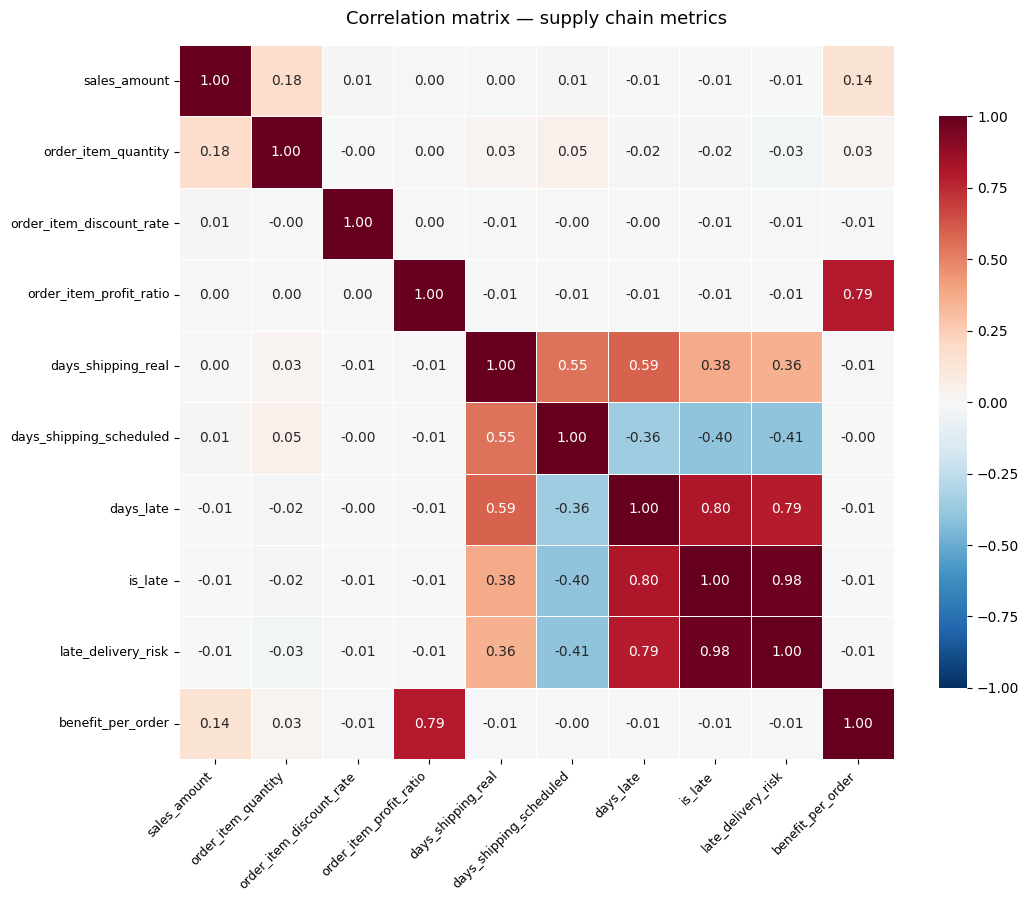


Strongest correlations with is_late:
late_delivery_risk          0.980265
days_late                   0.804865
days_shipping_scheduled    -0.401371
days_shipping_real          0.375106
order_item_quantity        -0.019701
sales_amount               -0.006459
order_item_discount_rate   -0.006225
benefit_per_order          -0.006191
order_item_profit_ratio    -0.005761


In [16]:
# Correlation Heatmap

numeric = query("""
    SELECT
        f.sales_amount,
        f.order_item_quantity,
        f.order_item_discount_rate,
        f.order_item_profit_ratio,
        f.days_shipping_real,
        f.days_shipping_scheduled,
        f.days_late,
        f.is_late,
        f.late_delivery_risk,
        f.benefit_per_order
    FROM fact_orders f
    LIMIT 50000
""")

corr = numeric.corr()

fig, ax = plt.subplots(figsize=(11, 9))

mask = corr.copy()
for col in mask.columns:
    mask[col] = False

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)

ax.set_title('Correlation matrix — supply chain metrics', fontsize=13, pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('../data/chart_06_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Print strongest correlations
print("\nStrongest correlations with is_late:")
corr_with_late = corr['is_late'].drop('is_late').sort_values(key=abs, ascending=False)
print(corr_with_late.to_string())

## Finding 6 — Late delivery is driven by shipping schedule, not order characteristics

- is_late correlates 0.98 with late_delivery_risk — validates our computed column
- is_late correlates -0.40 with days_shipping_scheduled — longer windows = fewer late orders
- sales_amount, discount_rate, profit_ratio all show ~0.00 correlation with is_late
- Order value and profitability have zero influence on whether an order arrives late

**Business implication:** Late delivery cannot be solved by prioritising 
high-value orders — the operational process treats all orders identically 
regardless of value. The fix is scheduling: either extend shipping windows 
to match actual delivery capability, or improve fulfilment speed to match 
current scheduling promises.

In [17]:
print("=" * 55)
print("  EDA COMPLETE — KEY FINDINGS SUMMARY")
print("=" * 55)
print("""
Finding 1 — Shipping mode drives late delivery
  First Class:   100% late rate (27,814 orders)
  Second Class:   79.7% late rate, avg 2 days late
  Standard Class: 39.8% late — but most volume (107,752)

Finding 2 — Late delivery is global and systemic
  All 23 regions: 51.9% to 60.7% late rate
  Western Europe: $3.45M revenue at risk (highest)
  Central America: $3.25M revenue at risk

Finding 3 — Fishing & Cleats drive most revenue at risk
  Fishing:  $3.97M revenue at risk
  Cleats:   $2.53M revenue at risk
  Top 5 categories: $12.75M combined at risk

Finding 4 — No improvement in 3 years
  Late rate flat at 55–60% from Jan 2015 to Jan 2018
  Order volume dropped 60% in late 2017 (data truncation)

Finding 5 — Customer segment has no impact
  Consumer/Corporate/Home Office: identical late rates
  All segments: ~$203 avg order value, ~12% margin

Finding 6 — Scheduling gap is the root cause
  is_late correlates -0.40 with days_shipping_scheduled
  Order value has zero correlation with late delivery
""")
print("=" * 55)
print("  Charts saved to /data/")
print("  Next: Phase 4 — Advanced SQL analysis")
print("=" * 55)

conn.close()
print("\nConnection closed.")

  EDA COMPLETE — KEY FINDINGS SUMMARY

Finding 1 — Shipping mode drives late delivery
  First Class:   100% late rate (27,814 orders)
  Second Class:   79.7% late rate, avg 2 days late
  Standard Class: 39.8% late — but most volume (107,752)

Finding 2 — Late delivery is global and systemic
  All 23 regions: 51.9% to 60.7% late rate
  Western Europe: $3.45M revenue at risk (highest)
  Central America: $3.25M revenue at risk

Finding 3 — Fishing & Cleats drive most revenue at risk
  Fishing:  $3.97M revenue at risk
  Cleats:   $2.53M revenue at risk
  Top 5 categories: $12.75M combined at risk

Finding 4 — No improvement in 3 years
  Late rate flat at 55–60% from Jan 2015 to Jan 2018
  Order volume dropped 60% in late 2017 (data truncation)

Finding 5 — Customer segment has no impact
  Consumer/Corporate/Home Office: identical late rates
  All segments: ~$203 avg order value, ~12% margin

Finding 6 — Scheduling gap is the root cause
  is_late correlates -0.40 with days_shipping_schedule